# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [3]:
import pandas as pd
import numpy as np

#Gerando valores
ud = np.random.normal(0,4,1000)
ud

array([ 6.14592503e+00,  1.77055531e+00,  7.09470564e+00,  2.99805952e+00,
        6.63982341e+00,  8.51992826e+00, -2.02974370e+00, -7.86583314e+00,
        4.88901712e-01, -7.19417845e-03, -2.24380283e-01, -2.01038740e+00,
        7.63903969e-01,  3.08601496e+00,  2.81745741e-01, -4.05146265e+00,
        4.34345135e-01, -9.51683541e+00, -4.94067512e+00,  2.96252285e+00,
        7.09500539e+00,  4.82373663e+00,  6.23496596e+00,  9.34060016e-01,
       -3.73712852e+00,  1.24629276e+00,  2.11301401e+00, -5.83576818e-01,
       -1.64682582e+00, -4.53746863e+00, -2.20287427e+00, -3.18923129e+00,
       -4.34892969e+00, -6.23592271e+00,  7.16099478e+00, -1.34566362e+01,
       -6.05094811e+00, -2.19466927e+00, -8.35006295e-02,  3.02530361e+00,
       -2.28763920e+00,  2.10932288e+00, -7.98189888e-01,  1.62889532e+00,
       -1.22238386e+00, -3.30781800e-01, -7.63870523e+00,  2.74441157e+00,
       -6.00173279e+00, -3.37436813e+00, -2.77531677e+00,  4.56084570e-01,
       -1.05280018e+01,  

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [4]:
#Criando 1000 genes
genes = np.random.randint(1000, size = 1000)

#Criando 1000 pacientes
df = pd.DataFrame(index= [f"Paciente {i}" for i in range(1, 1001)])

df["#Genes"] = genes
df["Expressão"] = ud
df

,#Genes,Expressão
Paciente 1,491,6.145925
Paciente 2,395,1.770555
Paciente 3,312,7.094706
Paciente 4,639,2.998060
Paciente 5,704,6.639823
...,...,...
Paciente 996,689,-4.794488
Paciente 997,697,0.093092
Paciente 998,577,-0.693120
Paciente 999,541,-4.899461


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: Irei categorizar os dados baseado no nível de expressão gênica

Abaixo de -2.0 -> Inibição Forte

-2.0 até -0.5 -> Inibição Leve

-0.5 até 0.5 -> Expressão Basal

0.5 até 2.0 -> Expressão Moderada

2.0 até 5.0 -> Expressão Alta  

Acima de 5.0 -> Super-Expressão

In [5]:
bins = [-np.inf, -5, -1.5, 1.5, 5, 8, np.inf]

labels = [
    'Inibição Severa',
    'Expressão Baixa',
    'Expressão Basal',
    'Expressão Moderada',
    'Expressão Alta',
    'Super-Expressão'
]

# Aplicando a lógica manual
df["Grupos"] = pd.cut(df["Expressão"], bins=bins, labels=labels)
df

,#Genes,Expressão,Grupos
Paciente 1,491,6.145925,Expressão Alta
Paciente 2,395,1.770555,Expressão Moderada
Paciente 3,312,7.094706,Expressão Alta
Paciente 4,639,2.998060,Expressão Moderada
Paciente 5,704,6.639823,Expressão Alta
...,...,...,...
Paciente 996,689,-4.794488,Expressão Baixa
Paciente 997,697,0.093092,Expressão Basal
Paciente 998,577,-0.693120,Expressão Basal
Paciente 999,541,-4.899461,Expressão Baixa


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [6]:
import pandas as pd

#Definindo função
def frequencia(serie:pd.Series) ->pd.DataFrame:
    freq = serie.value_counts(normalize=True).sort_index()

    tabela = pd.DataFrame({
        "frequencia": freq
    })

    return tabela

#Obtendo resultado
genes_1 = frequencia(df["#Genes"])
expressao = frequencia(df["Expressão"])

## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

### Expressão

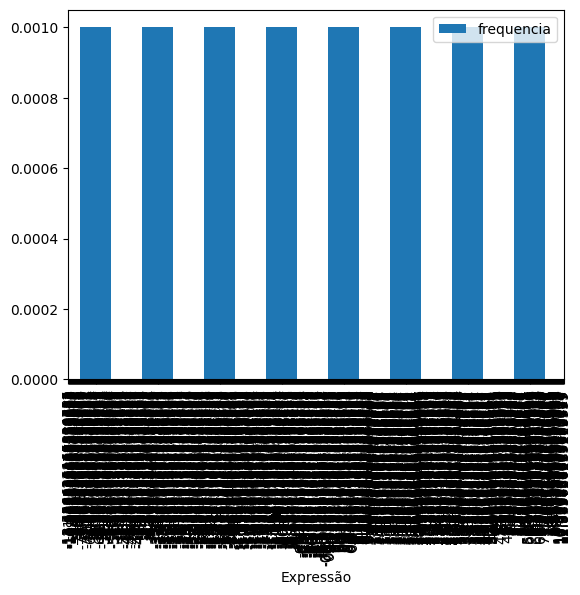

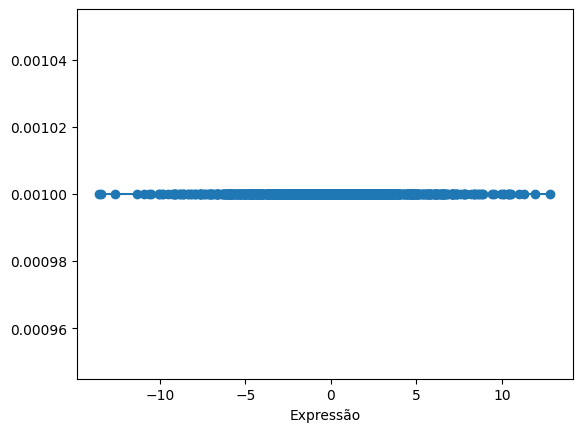

In [7]:
import matplotlib.pyplot as plt

#Gerando grafico de expressão -> Gráfico de barras
expressao.plot(kind="bar")
plt.show()

#Gerando grafico de expressão -> Gráfico de linhas

expressao['frequencia'].plot(kind='line', marker='o')
plt.show()



### Número

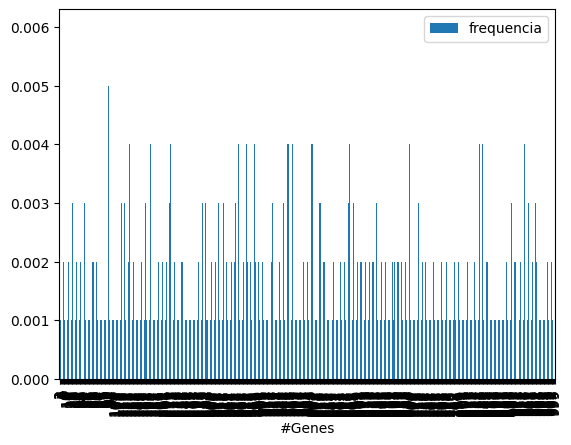

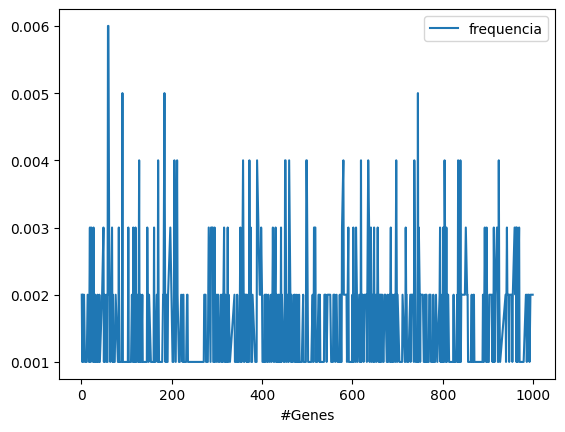

In [8]:
import matplotlib.pyplot as plt

#Gerando grafico de expressão -> Gráfico de barras
genes_1.plot(kind="bar")
plt.show()

#Gerando grafico de expressão -> Gráfico de linhas


genes_1.plot.line()
plt.show()


## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

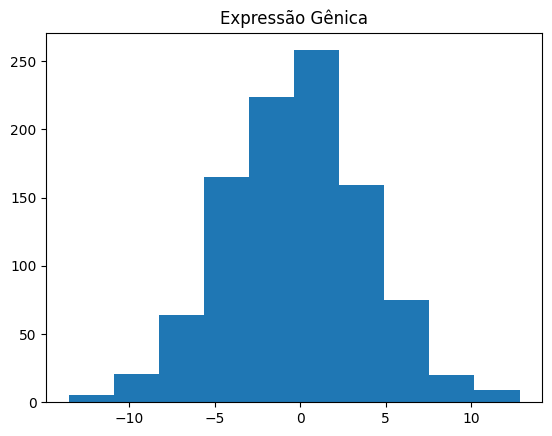

In [9]:
plt.hist(df['Expressão'])
plt.title('Expressão Gênica')
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

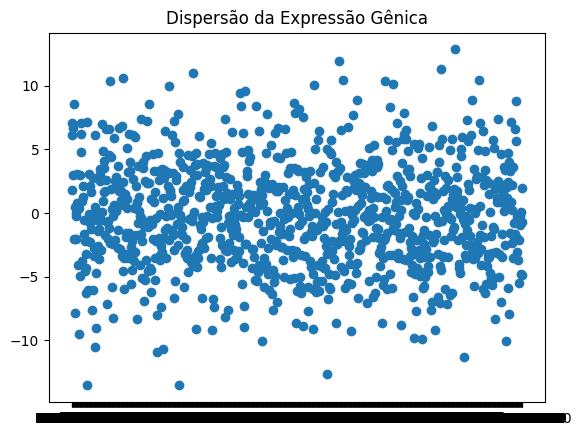

In [14]:
plt.scatter(df.index, df['Expressão'])
plt.title('Dispersão da Expressão Gênica')
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

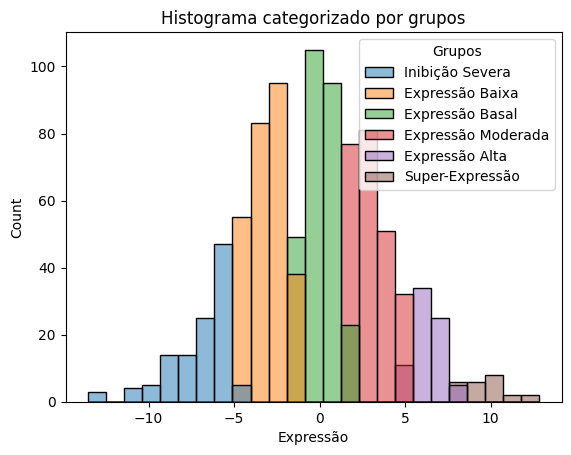

In [12]:
import seaborn as sns
sns.histplot(data=df, x='Expressão', hue='Grupos')
plt.title('Histograma categorizado por grupos')
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

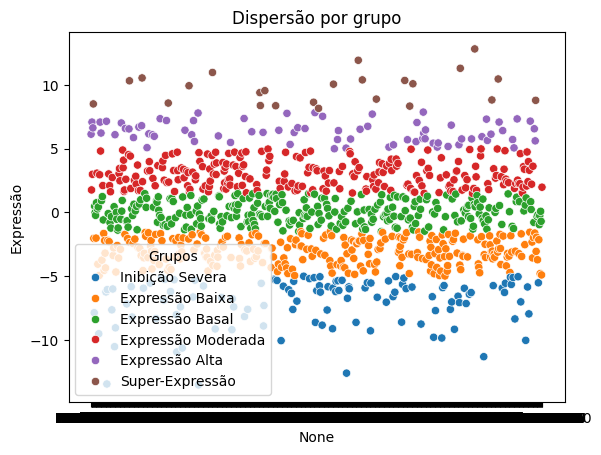

In [15]:
sns.scatterplot(data=df,x=df.index,y='Expressão',hue='Grupos')
plt.title('Dispersão por grupo')
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas|| Discreta|
| % de células positivas|| Contínua|
| Faixa de pH|| Contínua|
| Valor de pH|| Contínua|
| mol/L|| Contínua|
| UFC|| Dscreta|
| D.O.|| Contínua|
| Grupo Sanguíneo|| Nommina|
| Sorologia|| Nominal|

| Variável | Valor |

Número de células positivas -> Discreta

% de células positivas -> Contínua

Faixa de pH -> Ordinal

Valor de pH -> Contínua

mol/L -> Contínua

UFC -> Discreta

D.O. -> Contínua

Grupo Sanguíneo -> Nominal

Sorologia -> Nominal